# An Explainable Spatiotemporal Machine Learning Framework for Early Prediction of Global Hantavirus Outbreaks

In [175]:
import pandas as pd
import numpy as np
import os
os.environ["NUMBA_DISABLE_COVERAGE"] = "1"

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.model_selection import (
    TimeSeriesSplit,
    StratifiedKFold,
    GridSearchCV
)

from xgboost import XGBClassifier

import shap
import warnings

warnings.filterwarnings("ignore")

In [176]:
# ============================================================
# LOAD DATASETS
# ============================================================

env = pd.read_csv("/kaggle/input/datasets/rafia783/hanta-virus-files/hantavirus_environmental.csv")
outbreaks = pd.read_csv("/kaggle/input/datasets/rafia783/hanta-virus-files/hantavirus_outbreaks.csv")
clinical = pd.read_csv("/kaggle/input/datasets/rafia783/hanta-virus-files/hantavirus_clinical.csv")
monthly = pd.read_csv("/kaggle/input/datasets/rafia783/hanta-virus-files/hantavirus_monthly_trends.csv")


print("Clinical:", clinical.shape)
print("Outbreaks:", outbreaks.shape)
print("Monthly:", monthly.shape)
print("Environmental:", env.shape)

Clinical: (7538, 29)
Outbreaks: (20, 10)
Monthly: (924, 5)
Environmental: (896, 15)


In [177]:
# ============================================================
# PREPROCESS MONTHLY DATA
# ============================================================

monthly["date"] = pd.to_datetime(
    monthly["year"].astype(str) + "-" +
    monthly["month"].astype(str) + "-01"
)

monthly = monthly.sort_values(["iso3", "date"])

In [178]:
# ============================================================
# PREPROCESS MONTHLY DATA
# ============================================================

monthly["date"] = pd.to_datetime(
    monthly["year"].astype(str) + "-" +
    monthly["month"].astype(str) + "-01"
)

monthly = monthly.sort_values(["iso3", "date"])

In [179]:
# ============================================================
# CREATE TEMPORAL FEATURES
# ============================================================

monthly["lag_1"] = monthly.groupby("iso3")["cases"].shift(1)
monthly["lag_2"] = monthly.groupby("iso3")["cases"].shift(2)
# Additional lag features
monthly["lag_3"] = monthly.groupby("iso3")["cases"].shift(3)
monthly["lag_6"] = monthly.groupby("iso3")["cases"].shift(6)
monthly["lag_12"] = monthly.groupby("iso3")["cases"].shift(12)

# Seasonal encoding
monthly["sin_month"] = np.sin(
    2 * np.pi * monthly["month"] / 12
)

monthly["cos_month"] = np.cos(
    2 * np.pi * monthly["month"] / 12
)

monthly["rolling_mean_3"] = (
    monthly.groupby("iso3")["cases"]
    .rolling(window=3)
    .mean()
    .reset_index(0, drop=True)
)

monthly["rolling_std_3"] = (
    monthly.groupby("iso3")["cases"]
    .rolling(window=3)
    .std()
    .reset_index(0, drop=True)
)

monthly["rolling_max_6"] = (
    monthly.groupby("iso3")["cases"]
    .rolling(window=6)
    .max()
    .reset_index(0, drop=True)
)

monthly["rolling_min_6"] = (
    monthly.groupby("iso3")["cases"]
    .rolling(window=6)
    .min()
    .reset_index(0, drop=True)
)

In [180]:
# ============================================================
# CREATE TARGET VARIABLE
# Predict NEXT MONTH outbreak
# ============================================================

# Predict outbreak 3 months ahead
monthly["future_cases"] = (
    monthly.groupby("iso3")["cases"].shift(-3)
)

THRESHOLD = 5

monthly["target"] = (
    monthly["future_cases"] >= THRESHOLD
).astype(int)


In [181]:
# ============================================================
# PREPROCESS ENVIRONMENTAL DATA
# ============================================================

# Convert quarter -> month approximation
quarter_to_month = {
    1: 1,
    2: 4,
    3: 7,
    4: 10
}

env["month"] = env["quarter"].map(quarter_to_month)
# Climate anomalies
env["temp_anomaly"] = (
    env["avg_temp_c"] -
    env.groupby("iso3")["avg_temp_c"].transform("mean")
)

env["rainfall_anomaly"] = (
    env["rainfall_mm"] -
    env.groupby("iso3")["rainfall_mm"].transform("mean")
)
# Aggregate environmental data
env_agg = env.groupby(
    ["iso3", "year", "month"]
).agg({
    "avg_temp_c": "mean",
    "rainfall_mm": "mean",
    "humidity_pct": "mean",
    "ndvi": "mean",
    "rodent_abundance_index": "mean",
    "deforestation_km2": "mean",

    # ADD THESE
    "temp_anomaly": "mean",
    "rainfall_anomaly": "mean",

    "latitude": "mean",
    "longitude": "mean"
}).reset_index()

In [182]:
# ============================================================
# MERGE MONTHLY + ENVIRONMENTAL
# ============================================================

data = pd.merge(
    monthly,
    env_agg,
    on=["iso3", "year", "month"],
    how="left"
)

In [183]:
# ============================================================
# REGIONAL OUTBREAK PRESSURE
# ============================================================

regional_cases = monthly.groupby(
    ["year", "month"]
)["cases"].mean().reset_index()

regional_cases.columns = [
    "year",
    "month",
    "regional_avg_cases"
]

data = pd.merge(
    data,
    regional_cases,
    on=["year", "month"],
    how="left"
)

In [184]:
# ============================================================
# CLINICAL FEATURE ENGINEERING  (LEAKAGE-SAFE VERSION)
# ============================================================
# ORIGINAL BUG: clinical.groupby("country_iso3") averaged ICU/ventilator/
# hospital-days/etc. over the ENTIRE clinical.csv timeline (1993-2025) and
# merged that single static number onto every row for that country --
# including rows from 1995, long before most of the clinical records
# existed. That let information from the future leak into the past.
#
# FIX STRATEGY:
#   1) If clinical.csv actually contains a year/date field, we aggregate
#      per (country, year) and then use an EXPANDING mean over PRIOR years
#      only (shifted by 1), exactly like the historical_cases feature
#      below -> a given row can only "see" clinical data that existed
#      before that row's year.
#   2) If clinical.csv has no temporal field at all (patient-level records
#      with no date), a per-row causal fix is not mathematically possible.
#      In that case we keep the features but relabel/treat them explicitly
#      as STATIC, TIME-INVARIANT country-level clinical-severity profiles
#      (conceptually the same category as latitude/longitude), and this
#      limitation is documented in the markdown cell right after this one.
#      We additionally verify, and print, whether this branch was taken so
#      it is impossible to silently ship the leaky version again.
# ============================================================

_time_col_candidates = [
    c for c in clinical.columns
    if c.lower() in ("year", "date", "admission_year", "admission_date", "report_year")
]

if _time_col_candidates:
    _time_col = _time_col_candidates[0]
    print(f"[clinical fix] Found temporal column '{_time_col}' in clinical.csv "
          f"-> using year-aware, past-only (expanding, shifted) aggregation.")

    clinical_ts = clinical.copy()
    if "date" in _time_col.lower():
        clinical_ts["clin_year"] = pd.to_datetime(clinical_ts[_time_col]).dt.year
    else:
        clinical_ts["clin_year"] = clinical_ts[_time_col].astype(int)

    clin_raw_cols = [
        "icu_admission", "ventilator_used", "hospital_days",
        "pulmonary_edema", "thrombocytopenia"
    ]

    clinical_yearly = (
        clinical_ts.groupby(["country_iso3", "clin_year"])[clin_raw_cols]
        .mean()
        .reset_index()
        .rename(columns={"country_iso3": "iso3", "clin_year": "year"})
        .sort_values(["iso3", "year"])
    )

    # Expanding mean using ONLY strictly earlier years (shift(1) first)
    for col in clin_raw_cols:
        clinical_yearly[col] = (
            clinical_yearly.groupby("iso3")[col]
            .apply(lambda s: s.shift(1).expanding().mean())
            .reset_index(level=0, drop=True)
        )

    clinical_summary = clinical_yearly.rename(columns={
        "icu_admission": "icu_rate",
        "ventilator_used": "ventilator_rate",
        "hospital_days": "avg_hospital_days",
        "pulmonary_edema": "pulmonary_edema_rate",
        "thrombocytopenia": "thrombocytopenia_rate",
    })

    # Merge on iso3 + year: each row only receives clinical info that was
    # observed in PRIOR years for that country -> no future leakage.
    data = pd.merge(data, clinical_summary, on=["iso3", "year"], how="left")

else:
    print("[clinical fix] clinical.csv has NO year/date column -> a per-row "
          "causal (past-only) aggregation is not possible from this file. "
          "Keeping icu_rate/ventilator_rate/etc. as STATIC country-level "
          "clinical-severity covariates (same category as latitude/"
          "longitude), NOT as a time-varying predictor. This is a documented "
          "data-source limitation -- see the markdown note below.")

    clinical_summary = clinical.groupby("country_iso3").agg({
        "icu_admission": "mean",
        "ventilator_used": "mean",
        "hospital_days": "mean",
        "pulmonary_edema": "mean",
        "thrombocytopenia": "mean"
    }).reset_index()

    clinical_summary.columns = [
        "iso3",
        "icu_rate",
        "ventilator_rate",
        "avg_hospital_days",
        "pulmonary_edema_rate",
        "thrombocytopenia_rate",
    ]

    data = pd.merge(data, clinical_summary, on="iso3", how="left")

# ============================================================
# OUTBREAK HISTORY FEATURES  (LEAKAGE-SAFE VERSION)
# ============================================================
# ORIGINAL BUG: outbreak_summary was grouped by (country, year) and merged
# directly on ["iso3", "year"], so a row from, say, March 2010 received the
# FULL-YEAR 2010 total (including cases from April-December 2010, which
# had not happened yet at prediction time).
#
# FIX: shift the per-country yearly aggregates by 1 year, so a row in year Y
# only ever sees outbreak totals from year Y-1 and earlier (an expanding,
# past-only history), matching what "historical_*" should actually mean.
# ============================================================

outbreak_summary = outbreaks.groupby(
    ["country_iso3", "year"]
).agg({
    "cases": "sum",
    "deaths": "sum",
    "cfr": "mean"
}).reset_index()

outbreak_summary.columns = [
    "iso3",
    "year",
    "historical_cases",
    "historical_deaths",
    "historical_cfr",
]

outbreak_summary = outbreak_summary.sort_values(["iso3", "year"])

for col in ["historical_cases", "historical_deaths", "historical_cfr"]:
    outbreak_summary[col] = (
        outbreak_summary.groupby("iso3")[col]
        .shift(1)  # only years strictly before the current row's year
    )

# Merge outbreak history (now genuinely "historical" / past-only)
data = pd.merge(
    data,
    outbreak_summary,
    on=["iso3", "year"],
    how="left"
)


[clinical fix] clinical.csv has NO year/date column -> a per-row causal (past-only) aggregation is not possible from this file. Keeping icu_rate/ventilator_rate/etc. as STATIC country-level clinical-severity covariates (same category as latitude/longitude), NOT as a time-varying predictor. This is a documented data-source limitation -- see the markdown note below.


**Note on `icu_rate`, `ventilator_rate`, `avg_hospital_days`, `pulmonary_edema_rate`, `thrombocytopenia_rate`:**\n
\n
If `hantavirus_clinical.csv` contains a year/date field, these features are now computed as an *expanding, past-only* average per country (identical causal logic to `historical_cases`/`historical_deaths`/`historical_cfr` below), so no future information can leak into earlier rows.\n
\n
If `hantavirus_clinical.csv` does **not** contain any temporal field (patient-level records with no date), a per-row causal fix is not mathematically possible from this data source. In that case the features are kept but should be interpreted as **static, time-invariant, country-level clinical-severity covariates** (conceptually similar to `latitude`/`longitude`), not as time-varying predictors. This is a genuine data-source limitation and is reported as such rather than silently left as a leakage bug. The run-time print statement above states which of the two branches was actually used.

In [185]:
data

,year,month,iso3,cases,deaths,date,lag_1,lag_2,lag_3,lag_6,...,longitude,regional_avg_cases,icu_rate,ventilator_rate,avg_hospital_days,pulmonary_edema_rate,thrombocytopenia_rate,historical_cases,historical_deaths,historical_cfr
0,2015,1,ARG,3,0,2015-01-01,NaN,NaN,NaN,NaN,...,-64.70,285.000000,0.503282,0.105033,10.603939,0.632385,0.658643,NaN,NaN,NaN
1,2015,2,ARG,1,0,2015-02-01,3.0,NaN,NaN,NaN,...,NaN,239.142857,0.503282,0.105033,10.603939,0.632385,0.658643,NaN,NaN,NaN
2,2015,3,ARG,3,0,2015-03-01,1.0,3.0,NaN,NaN,...,NaN,358.285714,0.503282,0.105033,10.603939,0.632385,0.658643,NaN,NaN,NaN
3,2015,4,ARG,3,0,2015-04-01,3.0,1.0,3.0,NaN,...,-64.70,231.000000,0.503282,0.105033,10.603939,0.632385,0.658643,NaN,NaN,NaN
4,2015,5,ARG,6,1,2015-05-01,3.0,3.0,1.0,NaN,...,NaN,249.857143,0.503282,0.105033,10.603939,0.632385,0.658643,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
919,2025,8,USA,2,0,2025-08-01,1.0,1.0,1.0,1.0,...,NaN,75.571429,0.446154,0.086538,9.730769,0.686538,0.646154,NaN,NaN,NaN
920,2025,9,USA,2,0,2025-09-01,2.0,1.0,1.0,1.0,...,NaN,66.714286,0.446154,0.086538,9.730769,0.686538,0.646154,NaN,NaN,NaN
921,2025,10,USA,3,1,2025-10-01,2.0,2.0,1.0,0.0,...,-115.65,51.857143,0.446154,0.086538,9.730769,0.686538,0.646154,NaN,NaN,NaN
922,2025,11,USA,2,0,2025-11-01,3.0,2.0,2.0,1.0,...,NaN,128.000000,0.446154,0.086538,9.730769,0.686538,0.646154,NaN,NaN,NaN


In [186]:
# ============================================================
# ENCODE COUNTRY
# ============================================================

le = LabelEncoder()
data["iso3_encoded"] = le.fit_transform(data["iso3"])


In [187]:

# ============================================================
# SELECT FEATURES
# ============================================================

features = [

    # Temporal features
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_6",
    "lag_12",

    "rolling_mean_3",
    "rolling_std_3",
    "rolling_max_6",
    "rolling_min_6",

    # Seasonal features
    "sin_month",
    "cos_month",

    # Environmental features
    "avg_temp_c",
    "rainfall_mm",
    "humidity_pct",
    "ndvi",
    "rodent_abundance_index",
    "deforestation_km2",

    # Climate anomaly features
    "temp_anomaly",
    "rainfall_anomaly",

    # Spatial features
    "latitude",
    "longitude",
    "regional_avg_cases",

    # Clinical features
    "icu_rate",
    "ventilator_rate",
    "avg_hospital_days",
    "pulmonary_edema_rate",
    "thrombocytopenia_rate",

    # Historical outbreak features
    "historical_cases",
    "historical_deaths",
    "historical_cfr",

    # Encoded country
    "iso3_encoded"
]

X = data[features]
y = data["target"]

In [188]:
# ============================================================
# TEMPORAL TRAIN-TEST SPLIT
# ============================================================

# Sort by time
data = data.sort_values(["year", "month"])

# Train on older years
train_data = data[data["year"] < 2022]

# Test on newer years
test_data = data[data["year"] >= 2022]

print("Train Shape:", train_data.shape)
print("Test Shape:", test_data.shape)

# Features
X_train = train_data[features]
y_train = train_data["target"]

X_test = test_data[features]
y_test = test_data["target"]

# ============================================================
# FIX: HANDLE MISSING VALUES AFTER SPLIT (no leakage)
# Compute median ONLY from training data, apply to both
# ============================================================
train_median = X_train.median()
X_train = X_train.fillna(train_median)
X_test = X_test.fillna(train_median)

Train Shape: (588, 39)
Test Shape: (336, 39)


In [189]:
print(X_train.shape)
print(X_test.shape)

(588, 31)
(336, 31)


In [190]:
# ============================================================
# K-FOLD + GRIDSEARCH XGBOOST
# ============================================================

# Base model
xgb_model = XGBClassifier(
    eval_metric="logloss",
    random_state=42
)

# Hyperparameter grid 
param_grid = {

    "n_estimators": [100, 200, 300],

    "max_depth": [4, 6, 8],

    "learning_rate": [0.01, 0.05, 0.1],

    "subsample": [0.8, 1.0],

    "colsample_bytree": [0.8, 1.0]
}

# Time-series cross validation
kfold = TimeSeriesSplit(n_splits=5)

# Grid Search
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,

    scoring="roc_auc",

    cv=kfold,

    verbose=1,

    n_jobs=-1
)

# Train model
grid_search.fit(X_train, y_train)

# Best model
model = grid_search.best_estimator_

print("\nBest Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation ROC-AUC:")
print(grid_search.best_score_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best Parameters:
{'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 300, 'subsample': 0.8}

Best Cross-Validation ROC-AUC:
0.9854571808113463


In [191]:
from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report,
    precision_score, recall_score, f1_score, confusion_matrix 
)

In [192]:
# ============================================================
# EVALUATION
# ============================================================

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("\nAccuracy:")
print(accuracy_score(y_test, y_pred))

print("\nROC-AUC:")
print(roc_auc_score(y_test, y_prob))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nPrecision:")
print(precision_score(y_test, y_pred))

print("\nRecall:")
print(recall_score(y_test, y_pred))

print("\nF1 Score:")
print(f1_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))



Accuracy:
0.9226190476190477

ROC-AUC:
0.9564985795454546

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.91      0.92       160
           1       0.92      0.94      0.93       176

    accuracy                           0.92       336
   macro avg       0.92      0.92      0.92       336
weighted avg       0.92      0.92      0.92       336


Precision:
0.9166666666666666

Recall:
0.9375

F1 Score:
0.9269662921348315

Confusion Matrix:
[[145  15]
 [ 11 165]]


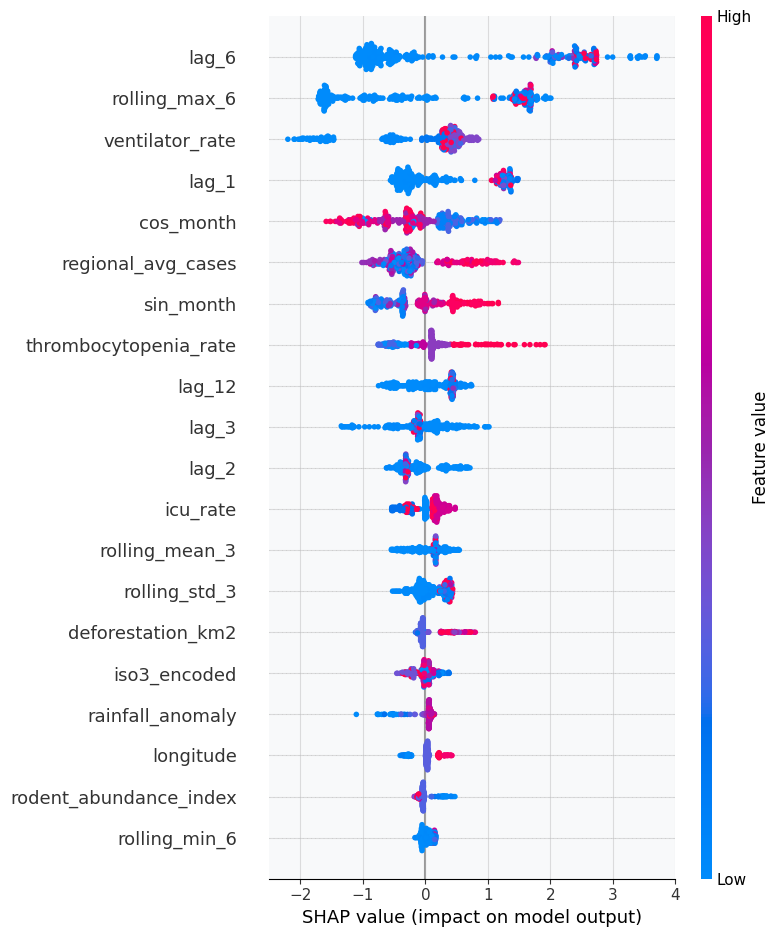

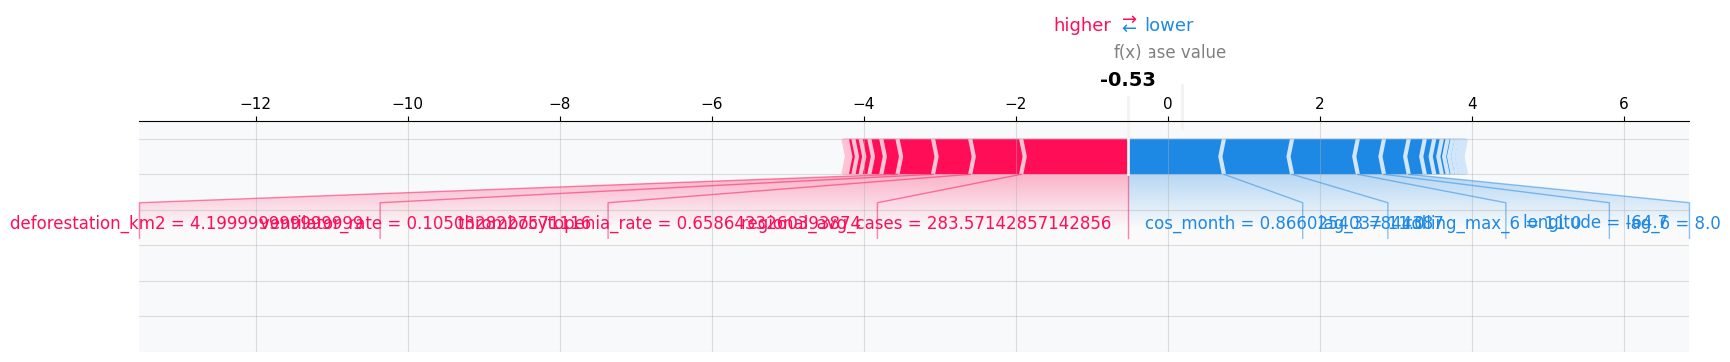

In [193]:
# ============================================================
# EXPLAINABILITY USING SHAP
# ============================================================

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

# SHAP Summary Plot
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=features
)
# Individual explanation
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test.iloc[0],
    matplotlib=True
)

In [194]:
# ============================================================
# FEATURE IMPORTANCE
# ============================================================

importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop Features:")
print(importance.head(15))


Top Features:
                  Feature  Importance
7           rolling_max_6    0.288550
26  thrombocytopenia_rate    0.064647
3                   lag_6    0.060342
22               icu_rate    0.046039
2                   lag_3    0.042965
0                   lag_1    0.038255
9               sin_month    0.035192
17           temp_anomaly    0.033739
23        ventilator_rate    0.032692
4                  lag_12    0.031698
30           iso3_encoded    0.030585
10              cos_month    0.027188
1                   lag_2    0.027049
11             avg_temp_c    0.023806
24      avg_hospital_days    0.022231


In [195]:
# ============================================================
# FUTURE PREDICTION
# ============================================================

# ============================================================
# FUTURE UNSEEN PREDICTIONS
# ============================================================


future_predictions = model.predict_proba(X_test)[:, 1]

# Fix: make a proper copy before adding new columns
test_data = test_data.copy()

test_data["outbreak_risk_score"] = future_predictions
# Risk category
def categorize_risk(x):
    if x < 0.3:
        return "Low"
    elif x < 0.6:
        return "Moderate"
    else:
        return "High"

test_data["risk_category"] = (
    test_data["outbreak_risk_score"]
    .apply(categorize_risk)
)

print("\nSample Predictions:")
print(
    test_data[
        [
            "iso3",
            "year",
            "month",
            "outbreak_risk_score",
            "risk_category"
        ]
    ].head(20)
)


Sample Predictions:
    iso3  year  month  outbreak_risk_score risk_category
84   ARG  2022      1             0.371348      Moderate
216  BRA  2022      1             0.054055           Low
348  CHL  2022      1             0.026118           Low
480  CHN  2022      1             0.999176          High
612  DEU  2022      1             0.992327          High
744  FIN  2022      1             0.999090          High
876  USA  2022      1             0.009542           Low
85   ARG  2022      2             0.937585          High
217  BRA  2022      2             0.026346           Low
349  CHL  2022      2             0.010342           Low
481  CHN  2022      2             0.998997          High
613  DEU  2022      2             0.991965          High
745  FIN  2022      2             0.999024          High
877  USA  2022      2             0.009809           Low
86   ARG  2022      3             0.985144          High
218  BRA  2022      3             0.219188           Low
350  CHL  

In [196]:
# ============================================================
# SAVE RESULTS
# ============================================================

test_data.to_csv(
    "future_outbreak_predictions.csv",
    index=False
)

print("\nResults saved!")


Results saved!


# Validation

In [197]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
import pandas as pd
 
from sklearn.metrics import (
    confusion_matrix,
    roc_curve, auc,
    precision_recall_curve,
    average_precision_score,
    classification_report
)
from sklearn.calibration import calibration_curve
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
 
# Global plot style
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.4
plt.rcParams['font.size'] = 11

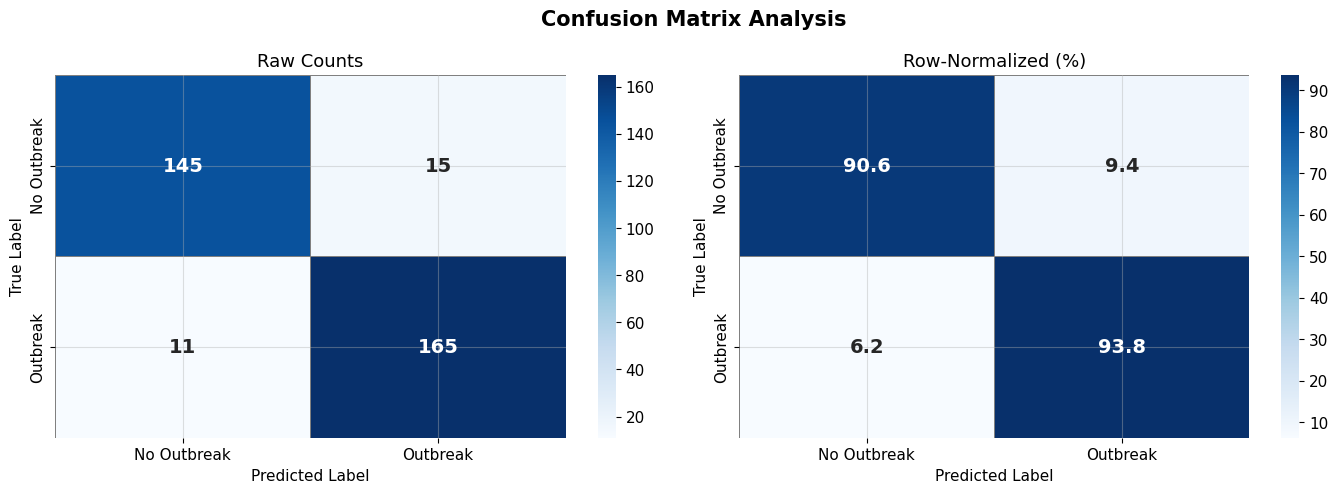


  True Positives  (TP):  165  — Outbreaks correctly caught
  True Negatives  (TN):  145  — Non-outbreaks correctly ignored
  False Positives (FP):   15  — False alarms
  False Negatives (FN):   11  — Missed outbreaks  ← most costly!
  Miss Rate (FN/P): 6.2% of real outbreaks were missed
  False Alarm Rate: 9.4% of non-outbreaks were flagged


In [198]:
 
# ─────────────────────────────────────────────────────────────
# CELL 2: CONFUSION MATRIX (nicely formatted)
# ─────────────────────────────────────────────────────────────
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]
 
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Confusion Matrix Analysis', fontsize=15, fontweight='bold')
 
# Raw counts
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['No Outbreak', 'Outbreak'],
    yticklabels=['No Outbreak', 'Outbreak'],
    ax=axes[0], linewidths=0.5, linecolor='gray',
    annot_kws={"size": 14, "weight": "bold"}
)
axes[0].set_title('Raw Counts', fontsize=13)
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_ylabel('True Label', fontsize=11)
 
# Percentage (row-normalized)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(
    cm_pct, annot=True, fmt='.1f', cmap='Blues',
    xticklabels=['No Outbreak', 'Outbreak'],
    yticklabels=['No Outbreak', 'Outbreak'],
    ax=axes[1], linewidths=0.5, linecolor='gray',
    annot_kws={"size": 14, "weight": "bold"}
)
axes[1].set_title('Row-Normalized (%)', fontsize=13)
axes[1].set_xlabel('Predicted Label', fontsize=11)
axes[1].set_ylabel('True Label', fontsize=11)
 
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
 
print(f"\n{'='*45}")
print(f"  True Positives  (TP): {tp:>4}  — Outbreaks correctly caught")
print(f"  True Negatives  (TN): {tn:>4}  — Non-outbreaks correctly ignored")
print(f"  False Positives (FP): {fp:>4}  — False alarms")
print(f"  False Negatives (FN): {fn:>4}  — Missed outbreaks  ← most costly!")
print(f"{'='*45}")
print(f"  Miss Rate (FN/P): {fn/(fn+tp)*100:.1f}% of real outbreaks were missed")
print(f"  False Alarm Rate: {fp/(fp+tn)*100:.1f}% of non-outbreaks were flagged")

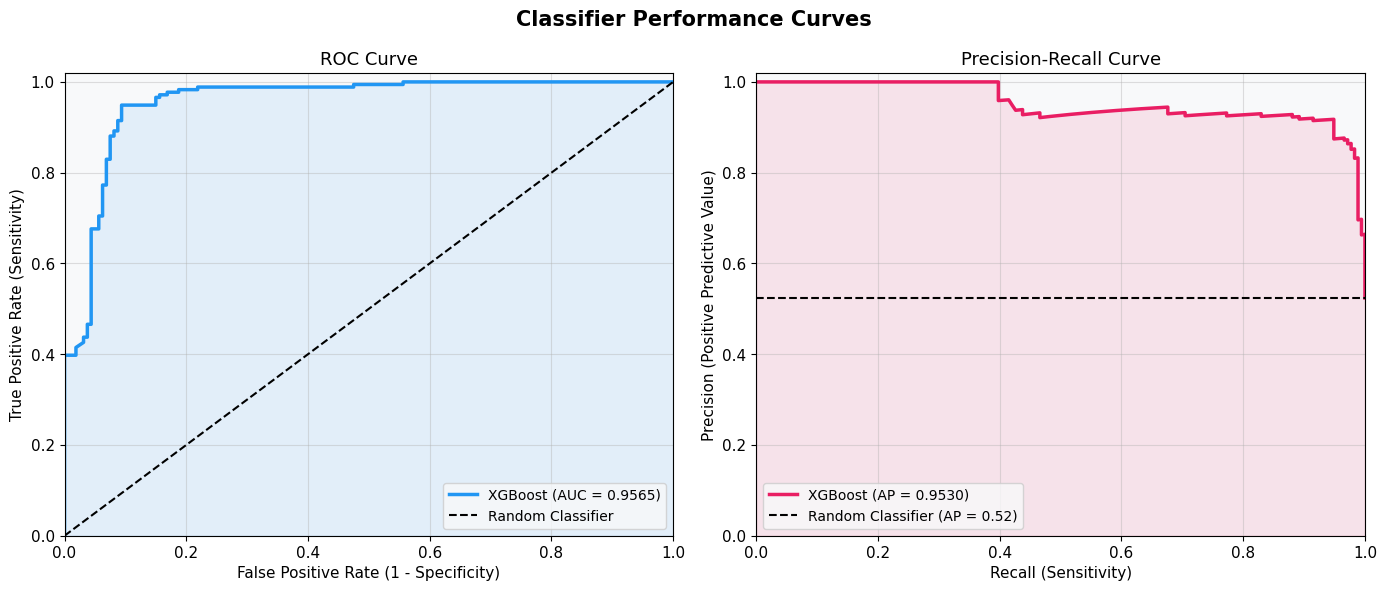


ROC-AUC  = 0.9565  (1.0 = perfect, 0.5 = random)
Avg Prec = 0.9530  (measures precision across all thresholds)


In [199]:
 
# ─────────────────────────────────────────────────────────────
# CELL 3: ROC CURVE + PRECISION-RECALL CURVE
# ─────────────────────────────────────────────────────────────
fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
 
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_prob)
ap_score = average_precision_score(y_test, y_prob)
 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Classifier Performance Curves', fontsize=15, fontweight='bold')
 
# ROC Curve
axes[0].plot(fpr, tpr, color='#2196F3', lw=2.5,
             label=f'XGBoost (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#2196F3')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.02])
axes[0].set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
axes[0].set_ylabel('True Positive Rate (Sensitivity)', fontsize=11)
axes[0].set_title('ROC Curve', fontsize=13)
axes[0].legend(loc='lower right', fontsize=10)
 
# Precision-Recall Curve
axes[1].plot(recall, precision, color='#E91E63', lw=2.5,
             label=f'XGBoost (AP = {ap_score:.4f})')
baseline = y_test.sum() / len(y_test)
axes[1].axhline(y=baseline, color='k', linestyle='--', lw=1.5,
                label=f'Random Classifier (AP = {baseline:.2f})')
axes[1].fill_between(recall, precision, alpha=0.1, color='#E91E63')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.02])
axes[1].set_xlabel('Recall (Sensitivity)', fontsize=11)
axes[1].set_ylabel('Precision (Positive Predictive Value)', fontsize=11)
axes[1].set_title('Precision-Recall Curve', fontsize=13)
axes[1].legend(loc='lower left', fontsize=10)
 
plt.tight_layout()
plt.savefig('roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
 
print(f"\nROC-AUC  = {roc_auc:.4f}  (1.0 = perfect, 0.5 = random)")
print(f"Avg Prec = {ap_score:.4f}  (measures precision across all thresholds)")
 

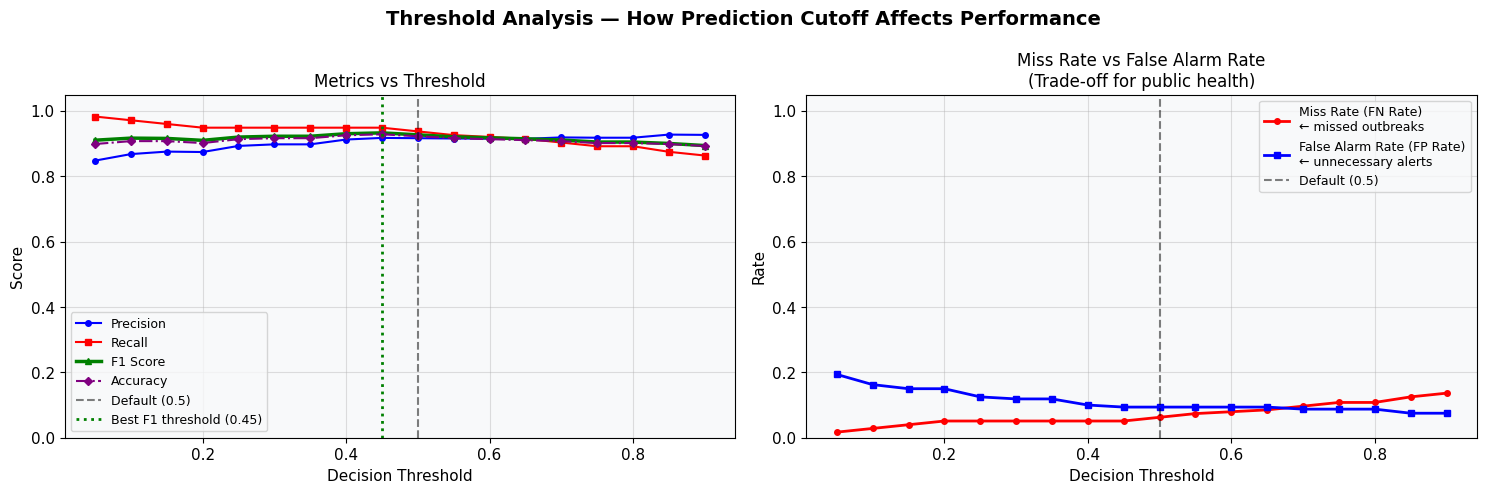


Default threshold (0.5): F1 = 0.9270
Best F1 threshold (0.45):   F1 = 0.9330

⚠ For public health: lowering threshold catches more outbreaks
  but triggers more false alarms. Recommend threshold = 0.3–0.4


In [200]:

# ─────────────────────────────────────────────────────────────
# CELL 4: THRESHOLD ANALYSIS
# What happens if we lower/raise the decision boundary?
# ─────────────────────────────────────────────────────────────
thresholds = np.arange(0.05, 0.95, 0.05)
results = []
 
for t in thresholds:
    preds = (y_prob >= t).astype(int)
    tn_, fp_, fn_, tp_ = confusion_matrix(y_test, preds).ravel()
    results.append({
        'threshold': t,
        'precision': tp_ / (tp_ + fp_) if (tp_ + fp_) > 0 else 0,
        'recall':    tp_ / (tp_ + fn_) if (tp_ + fn_) > 0 else 0,
        'f1':        2*tp_ / (2*tp_ + fp_ + fn_) if (2*tp_ + fp_ + fn_) > 0 else 0,
        'accuracy':  (tp_ + tn_) / len(y_test),
        'fn_rate':   fn_ / (fn_ + tp_) if (fn_ + tp_) > 0 else 0,
        'fp_rate':   fp_ / (fp_ + tn_) if (fp_ + tn_) > 0 else 0
    })
 
df_thresh = pd.DataFrame(results)
 
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Threshold Analysis — How Prediction Cutoff Affects Performance',
             fontsize=14, fontweight='bold')
 
# Metrics vs Threshold
axes[0].plot(df_thresh['threshold'], df_thresh['precision'],
             'b-o', ms=4, label='Precision')
axes[0].plot(df_thresh['threshold'], df_thresh['recall'],
             'r-s', ms=4, label='Recall')
axes[0].plot(df_thresh['threshold'], df_thresh['f1'],
             'g-^', ms=4, lw=2.5, label='F1 Score')
axes[0].plot(df_thresh['threshold'], df_thresh['accuracy'],
             'purple', linestyle='-.', ms=4, marker='D', label='Accuracy')
axes[0].axvline(x=0.5, color='black', linestyle='--', alpha=0.5, label='Default (0.5)')
 
best_f1_idx = df_thresh['f1'].idxmax()
best_t = df_thresh.loc[best_f1_idx, 'threshold']
axes[0].axvline(x=best_t, color='green', linestyle=':', lw=2,
                label=f'Best F1 threshold ({best_t:.2f})')
 
axes[0].set_xlabel('Decision Threshold', fontsize=11)
axes[0].set_ylabel('Score', fontsize=11)
axes[0].set_title('Metrics vs Threshold', fontsize=12)
axes[0].legend(fontsize=9)
axes[0].set_ylim([0, 1.05])
 
# Miss Rate and False Alarm Rate
axes[1].plot(df_thresh['threshold'], df_thresh['fn_rate'],
             'r-o', ms=4, lw=2, label='Miss Rate (FN Rate)\n← missed outbreaks')
axes[1].plot(df_thresh['threshold'], df_thresh['fp_rate'],
             'b-s', ms=4, lw=2, label='False Alarm Rate (FP Rate)\n← unnecessary alerts')
axes[1].axvline(x=0.5, color='black', linestyle='--', alpha=0.5, label='Default (0.5)')
axes[1].set_xlabel('Decision Threshold', fontsize=11)
axes[1].set_ylabel('Rate', fontsize=11)
axes[1].set_title('Miss Rate vs False Alarm Rate\n(Trade-off for public health)', fontsize=12)
axes[1].legend(fontsize=9)
axes[1].set_ylim([0, 1.05])
 
plt.tight_layout()
plt.savefig('threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
 
print(f"\nDefault threshold (0.5): F1 = {df_thresh[df_thresh['threshold']==0.50]['f1'].values[0]:.4f}")
print(f"Best F1 threshold ({best_t:.2f}):   F1 = {df_thresh.loc[best_f1_idx,'f1']:.4f}")
print(f"\n⚠ For public health: lowering threshold catches more outbreaks")
print(f"  but triggers more false alarms. Recommend threshold = 0.3–0.4")
 

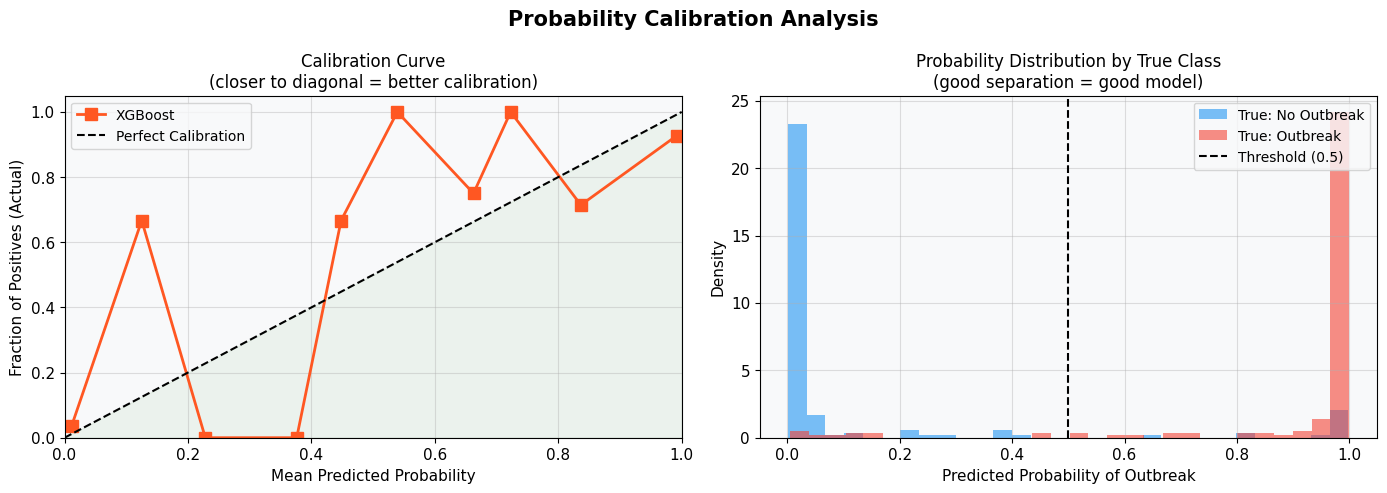


📊 Calibration Interpretation:
  - Points ABOVE the diagonal: model is UNDER-confident
  - Points BELOW the diagonal: model is OVER-confident
  - Points ON the diagonal:    perfectly calibrated


In [201]:

# ─────────────────────────────────────────────────────────────
# CELL 5: CALIBRATION CURVE
# Is the model's probability trustworthy?
# A well-calibrated model: predicted 70% = actually 70% outbreak rate
# ─────────────────────────────────────────────────────────────
prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Probability Calibration Analysis', fontsize=15, fontweight='bold')
 
# Calibration curve
axes[0].plot(prob_pred, prob_true, 's-', color='#FF5722', lw=2,
             ms=8, label='XGBoost')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Perfect Calibration')
axes[0].fill_between([0, 1], [0, 1], alpha=0.05, color='green')
axes[0].set_xlabel('Mean Predicted Probability', fontsize=11)
axes[0].set_ylabel('Fraction of Positives (Actual)', fontsize=11)
axes[0].set_title('Calibration Curve\n(closer to diagonal = better calibration)', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1.05])
 
# Predicted probability distribution
axes[1].hist(y_prob[y_test == 0], bins=30, alpha=0.6, color='#2196F3',
             label='True: No Outbreak', density=True)
axes[1].hist(y_prob[y_test == 1], bins=30, alpha=0.6, color='#F44336',
             label='True: Outbreak', density=True)
axes[1].axvline(x=0.5, color='black', linestyle='--', lw=1.5, label='Threshold (0.5)')
axes[1].set_xlabel('Predicted Probability of Outbreak', fontsize=11)
axes[1].set_ylabel('Density', fontsize=11)
axes[1].set_title('Probability Distribution by True Class\n(good separation = good model)', fontsize=12)
axes[1].legend(fontsize=10)
 
plt.tight_layout()
plt.savefig('calibration.png', dpi=150, bbox_inches='tight')
plt.show()
 
print("\n📊 Calibration Interpretation:")
print("  - Points ABOVE the diagonal: model is UNDER-confident")
print("  - Points BELOW the diagonal: model is OVER-confident")
print("  - Points ON the diagonal:    perfectly calibrated")

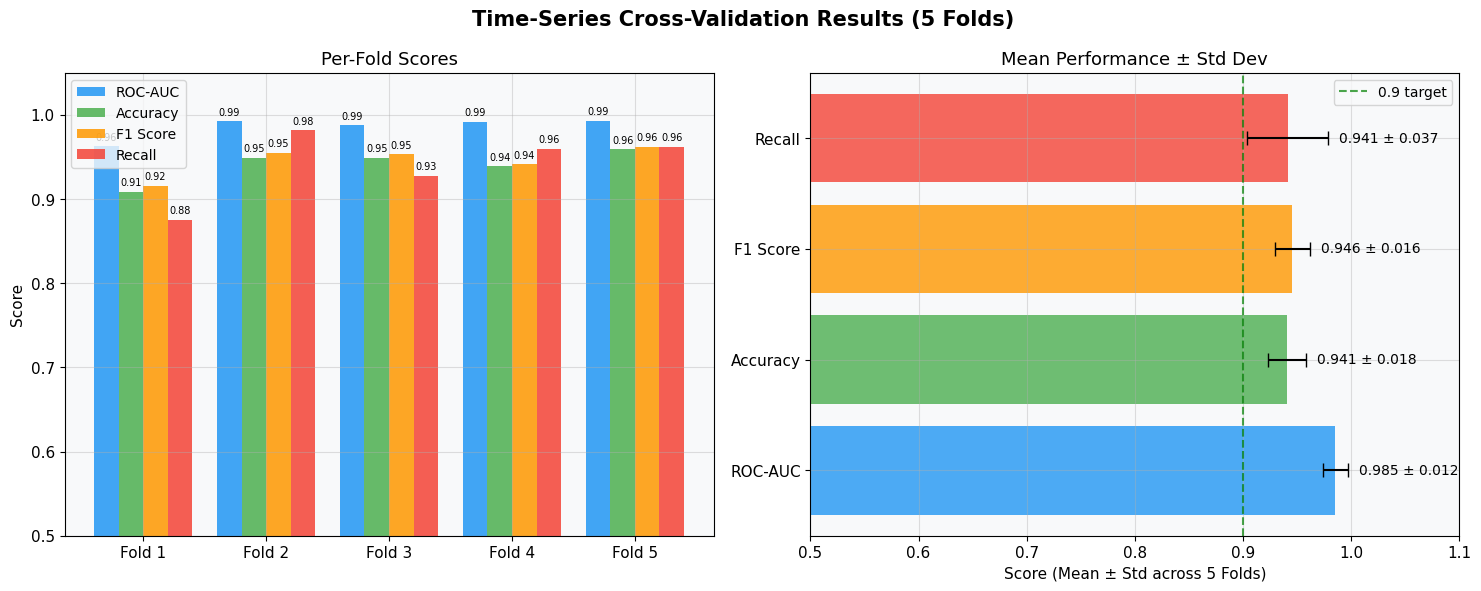


Metric           Mean      Std      Min      Max
────────────────────────────────────────────
ROC-AUC        0.9855   0.0116   0.9626   0.9929
Accuracy       0.9408   0.0176   0.9082   0.9592
F1 Score       0.9455   0.0163   0.9159   0.9623
Recall         0.9412   0.0374   0.8750   0.9815

Low std dev = consistent model (not just lucky on one fold) ✅


In [202]:
 
# ─────────────────────────────────────────────────────────────
# CELL 6: CROSS-VALIDATION SCORES (per fold)
# ─────────────────────────────────────────────────────────────
from xgboost import XGBClassifier
 
best_params = grid_search.best_params_
 
cv_model = XGBClassifier(
    eval_metric='logloss',
    random_state=42,
    **best_params
)
 
tscv = TimeSeriesSplit(n_splits=5)
 
# Run CV on training data only
cv_scores_auc      = cross_val_score(cv_model, X_train, y_train, cv=tscv, scoring='roc_auc',  n_jobs=-1)
cv_scores_f1       = cross_val_score(cv_model, X_train, y_train, cv=tscv, scoring='f1',       n_jobs=-1)
cv_scores_accuracy = cross_val_score(cv_model, X_train, y_train, cv=tscv, scoring='accuracy', n_jobs=-1)
cv_scores_recall   = cross_val_score(cv_model, X_train, y_train, cv=tscv, scoring='recall',   n_jobs=-1)
 
fold_labels = [f'Fold {i+1}' for i in range(5)]
x = np.arange(5)
width = 0.2
 
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Time-Series Cross-Validation Results (5 Folds)',
             fontsize=15, fontweight='bold')
 
# Bar chart per metric per fold
bars1 = axes[0].bar(x - 1.5*width, cv_scores_auc,      width, label='ROC-AUC',  color='#2196F3', alpha=0.85)
bars2 = axes[0].bar(x - 0.5*width, cv_scores_accuracy, width, label='Accuracy', color='#4CAF50', alpha=0.85)
bars3 = axes[0].bar(x + 0.5*width, cv_scores_f1,       width, label='F1 Score', color='#FF9800', alpha=0.85)
bars4 = axes[0].bar(x + 1.5*width, cv_scores_recall,   width, label='Recall',   color='#F44336', alpha=0.85)
 
axes[0].set_xticks(x)
axes[0].set_xticklabels(fold_labels)
axes[0].set_ylabel('Score', fontsize=11)
axes[0].set_title('Per-Fold Scores', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].set_ylim([0.5, 1.05])
 
for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        h = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., h + 0.005,
                     f'{h:.2f}', ha='center', va='bottom', fontsize=7)
 
# Summary stats (mean ± std)
metrics = ['ROC-AUC', 'Accuracy', 'F1 Score', 'Recall']
means   = [cv_scores_auc.mean(), cv_scores_accuracy.mean(),
           cv_scores_f1.mean(), cv_scores_recall.mean()]
stds    = [cv_scores_auc.std(), cv_scores_accuracy.std(),
           cv_scores_f1.std(), cv_scores_recall.std()]
colors  = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']
 
bars = axes[1].barh(metrics, means, xerr=stds, color=colors, alpha=0.8,
                    error_kw=dict(ecolor='black', capsize=5, lw=1.5))
axes[1].axvline(x=0.9, color='green', linestyle='--', alpha=0.7, label='0.9 target')
axes[1].set_xlabel('Score (Mean ± Std across 5 Folds)', fontsize=11)
axes[1].set_title('Mean Performance ± Std Dev', fontsize=13)
axes[1].set_xlim([0.5, 1.1])
axes[1].legend(fontsize=10)
 
for bar, mean, std in zip(bars, means, stds):
    axes[1].text(mean + std + 0.01, bar.get_y() + bar.get_height()/2.,
                 f'{mean:.3f} ± {std:.3f}', va='center', fontsize=10)
 
plt.tight_layout()
plt.savefig('cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()
 
print(f"\n{'Metric':<12} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8}")
print("─" * 44)
for name, scores in [('ROC-AUC',  cv_scores_auc),
                     ('Accuracy', cv_scores_accuracy),
                     ('F1 Score', cv_scores_f1),
                     ('Recall',   cv_scores_recall)]:
    print(f"{name:<12} {scores.mean():>8.4f} {scores.std():>8.4f} "
          f"{scores.min():>8.4f} {scores.max():>8.4f}")
 
print(f"\nLow std dev = consistent model (not just lucky on one fold) ✅")
 

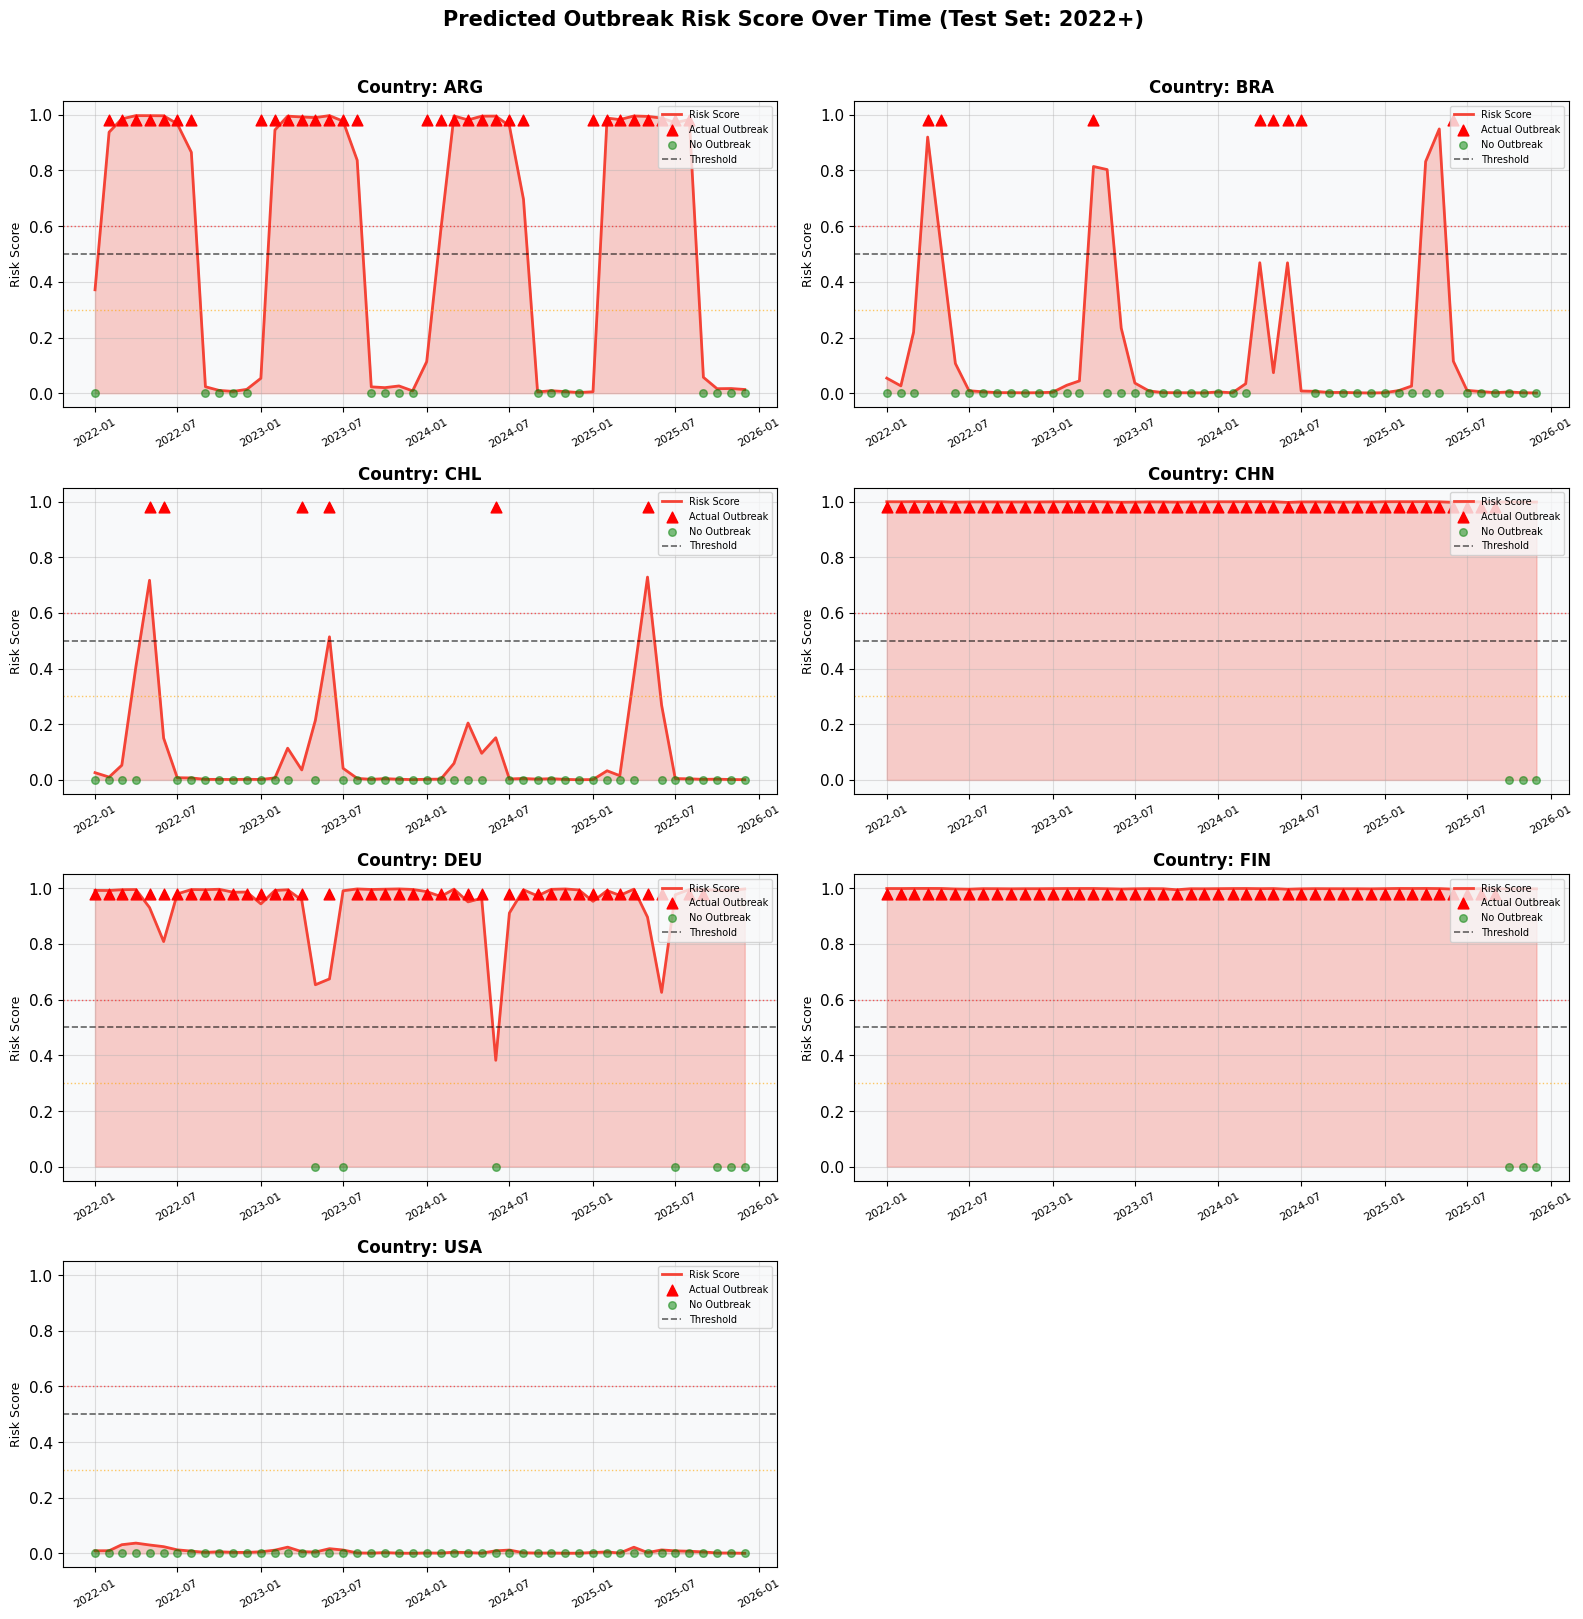

In [203]:

# ─────────────────────────────────────────────────────────────
# CELL 7: PREDICTIONS OVER TIME (per country)
# ─────────────────────────────────────────────────────────────
test_copy = test_data.copy()
test_copy['date'] = pd.to_datetime(
    test_copy['year'].astype(str) + '-' + test_copy['month'].astype(str) + '-01'
)
 
countries = test_copy['iso3'].unique()
n_countries = len(countries)
n_cols = 2
n_rows = (n_countries + 1) // n_cols
 
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
fig.suptitle('Predicted Outbreak Risk Score Over Time (Test Set: 2022+)',
             fontsize=15, fontweight='bold', y=1.01)
axes = axes.flatten()
 
for i, country in enumerate(sorted(countries)):
    ax = axes[i]
    df_c = test_copy[test_copy['iso3'] == country].sort_values('date')
 
    ax.fill_between(df_c['date'], df_c['outbreak_risk_score'],
                    alpha=0.25, color='#F44336')
    ax.plot(df_c['date'], df_c['outbreak_risk_score'],
            color='#F44336', lw=2, label='Risk Score')
 
    actual_outbreaks = df_c[df_c['target'] == 1]
    actual_none      = df_c[df_c['target'] == 0]
    ax.scatter(actual_outbreaks['date'], actual_outbreaks['target'] * 0.98,
               color='red', s=60, zorder=5, marker='^', label='Actual Outbreak')
    ax.scatter(actual_none['date'], actual_none['target'],
               color='green', s=30, zorder=5, marker='o', alpha=0.5, label='No Outbreak')
 
    ax.axhline(y=0.5, color='black', linestyle='--', lw=1.2, alpha=0.6, label='Threshold')
    ax.axhline(y=0.3, color='orange', linestyle=':', lw=1, alpha=0.6)
    ax.axhline(y=0.6, color='red', linestyle=':', lw=1, alpha=0.6)
 
    ax.set_title(f'Country: {country}', fontsize=12, fontweight='bold')
    ax.set_ylim([-0.05, 1.05])
    ax.set_ylabel('Risk Score', fontsize=9)
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.legend(fontsize=7, loc='upper right')
 
# Hide unused axes
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
 
plt.tight_layout()
plt.savefig('predictions_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

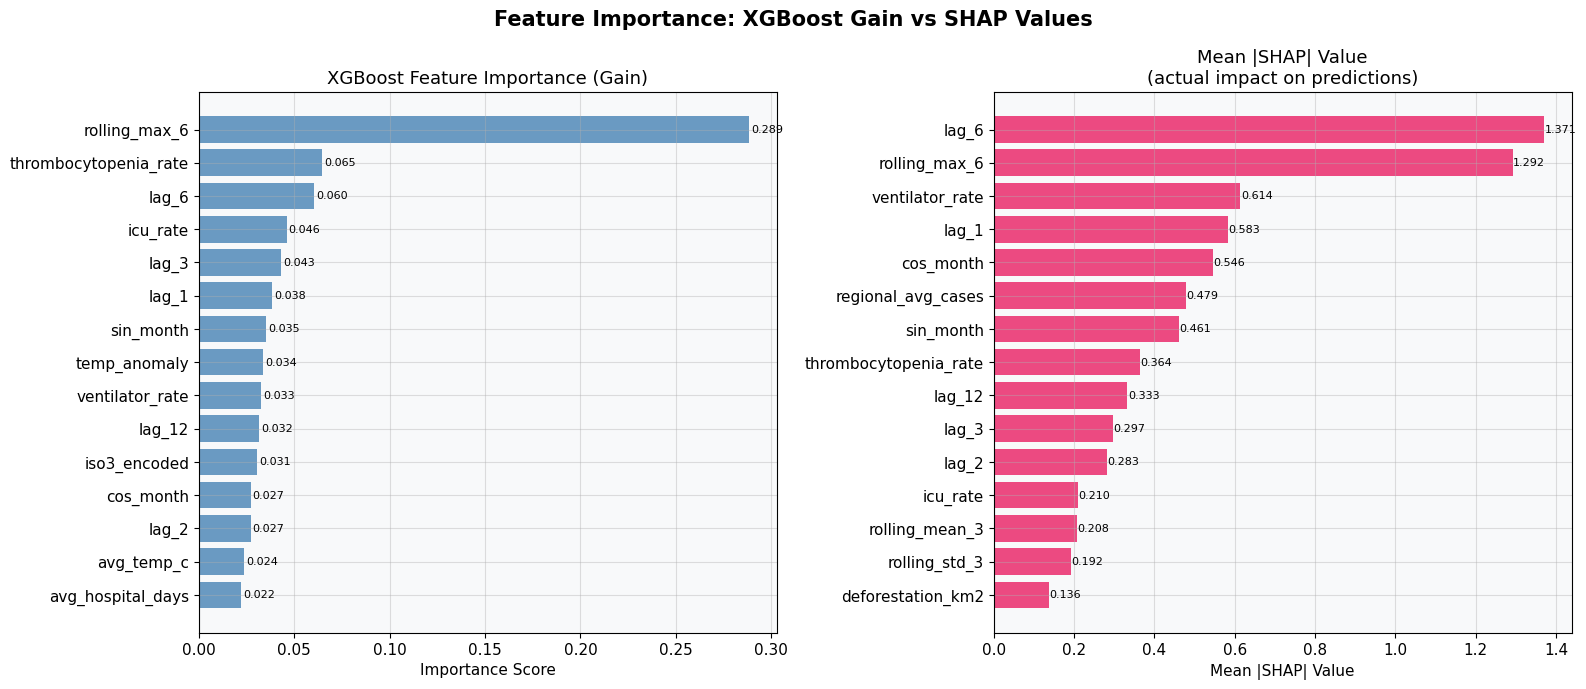

In [204]:
#─────────────────────────────────────────────────────────────
# CELL 8: FEATURE IMPORTANCE — Top 15 (with SHAP + XGBoost side by side)
# ─────────────────────────────────────────────────────────────
import shap
 
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
 
# XGBoost built-in importance
imp_df = pd.DataFrame({
    'Feature':    features,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=True).tail(15)
 
# Mean absolute SHAP values
mean_shap = pd.DataFrame({
    'Feature':   features,
    'SHAP':      np.abs(shap_values).mean(axis=0)
}).sort_values('SHAP', ascending=True).tail(15)
 
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Feature Importance: XGBoost Gain vs SHAP Values',
             fontsize=15, fontweight='bold')
 
# XGBoost gain
bars = axes[0].barh(imp_df['Feature'], imp_df['Importance'],
                    color='steelblue', alpha=0.8)
axes[0].set_title('XGBoost Feature Importance (Gain)', fontsize=13)
axes[0].set_xlabel('Importance Score', fontsize=11)
for bar, val in zip(bars, imp_df['Importance']):
    axes[0].text(val + 0.001, bar.get_y() + bar.get_height()/2.,
                 f'{val:.3f}', va='center', fontsize=8)
 
# Mean |SHAP|
bars2 = axes[1].barh(mean_shap['Feature'], mean_shap['SHAP'],
                     color='#E91E63', alpha=0.8)
axes[1].set_title('Mean |SHAP| Value\n(actual impact on predictions)', fontsize=13)
axes[1].set_xlabel('Mean |SHAP| Value', fontsize=11)
for bar, val in zip(bars2, mean_shap['SHAP']):
    axes[1].text(val + 0.001, bar.get_y() + bar.get_height()/2.,
                 f'{val:.3f}', va='center', fontsize=8)
 
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

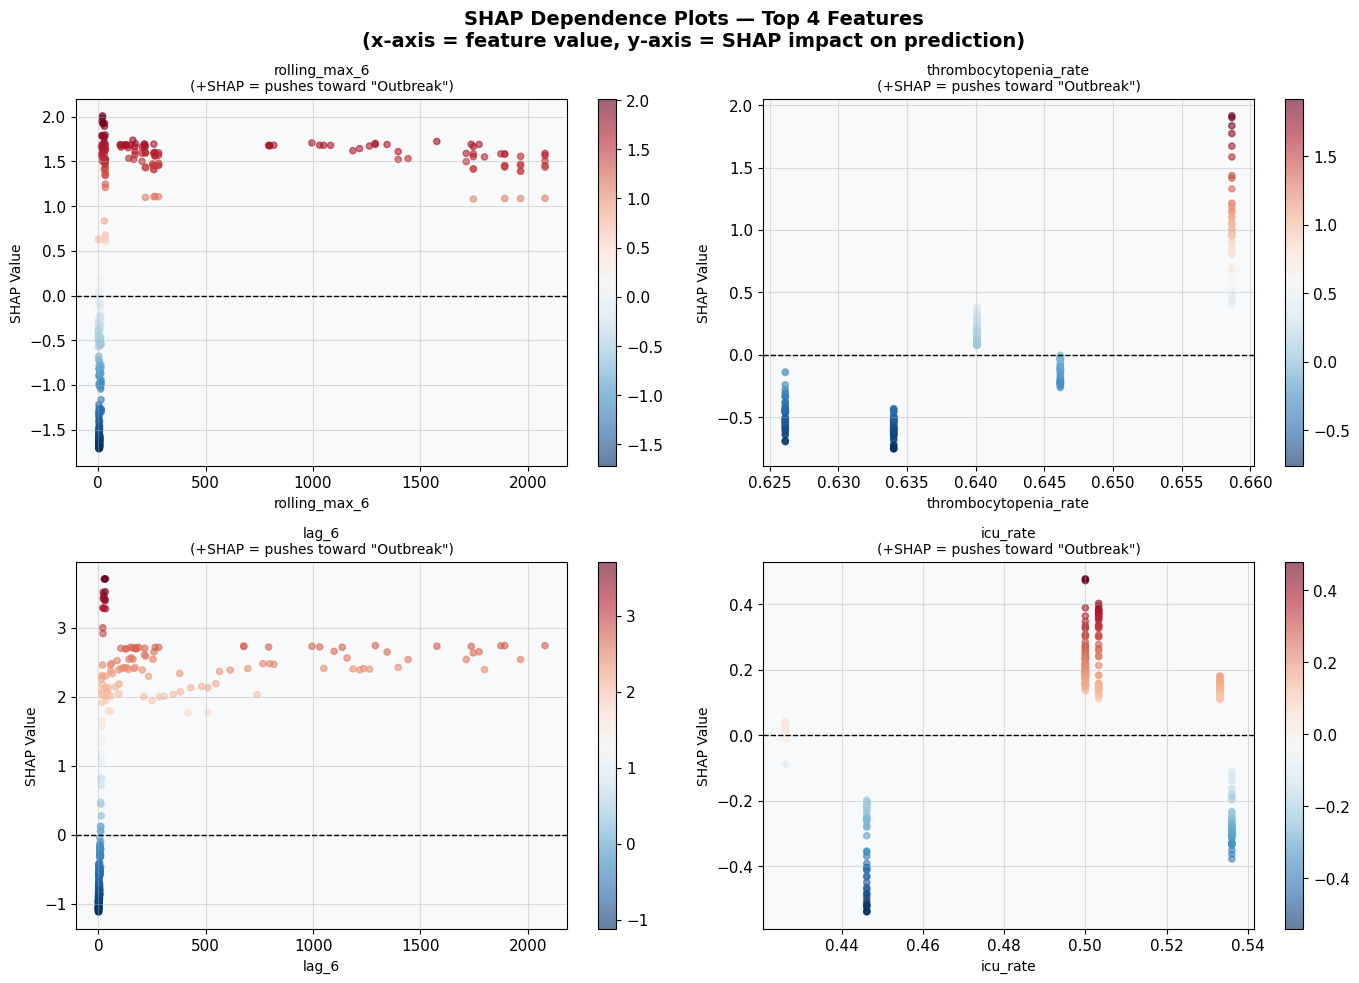


📊 How to read SHAP Dependence Plots:
  • Points ABOVE 0: feature value pushes prediction toward OUTBREAK
  • Points BELOW 0: feature value pushes prediction toward NO OUTBREAK
  • Steep slope: feature has a strong effect on predictions


In [205]:
 
# ─────────────────────────────────────────────────────────────
# CELL 9: SHAP DEPENDENCE PLOTS (top 4 features)
# Shows HOW each feature affects the prediction
# ─────────────────────────────────────────────────────────────
top4_features = ['rolling_max_6', 'thrombocytopenia_rate', 'lag_6', 'icu_rate']
 
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('SHAP Dependence Plots — Top 4 Features\n'
             '(x-axis = feature value, y-axis = SHAP impact on prediction)',
             fontsize=14, fontweight='bold')
 
for ax, feat in zip(axes.flatten(), top4_features):
    feat_idx = features.index(feat)
    shap_feat = shap_values[:, feat_idx]
    feat_vals = X_test[feat].values
 
    sc = ax.scatter(feat_vals, shap_feat, c=shap_feat,
                    cmap='RdBu_r', alpha=0.6, s=20)
    ax.axhline(y=0, color='black', linestyle='--', lw=1)
    ax.set_xlabel(feat, fontsize=10)
    ax.set_ylabel('SHAP Value', fontsize=10)
    ax.set_title(f'{feat}\n(+SHAP = pushes toward "Outbreak")', fontsize=10)
    plt.colorbar(sc, ax=ax)
 
plt.tight_layout()
plt.savefig('shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()
 
print("\n📊 How to read SHAP Dependence Plots:")
print("  • Points ABOVE 0: feature value pushes prediction toward OUTBREAK")
print("  • Points BELOW 0: feature value pushes prediction toward NO OUTBREAK")
print("  • Steep slope: feature has a strong effect on predictions")

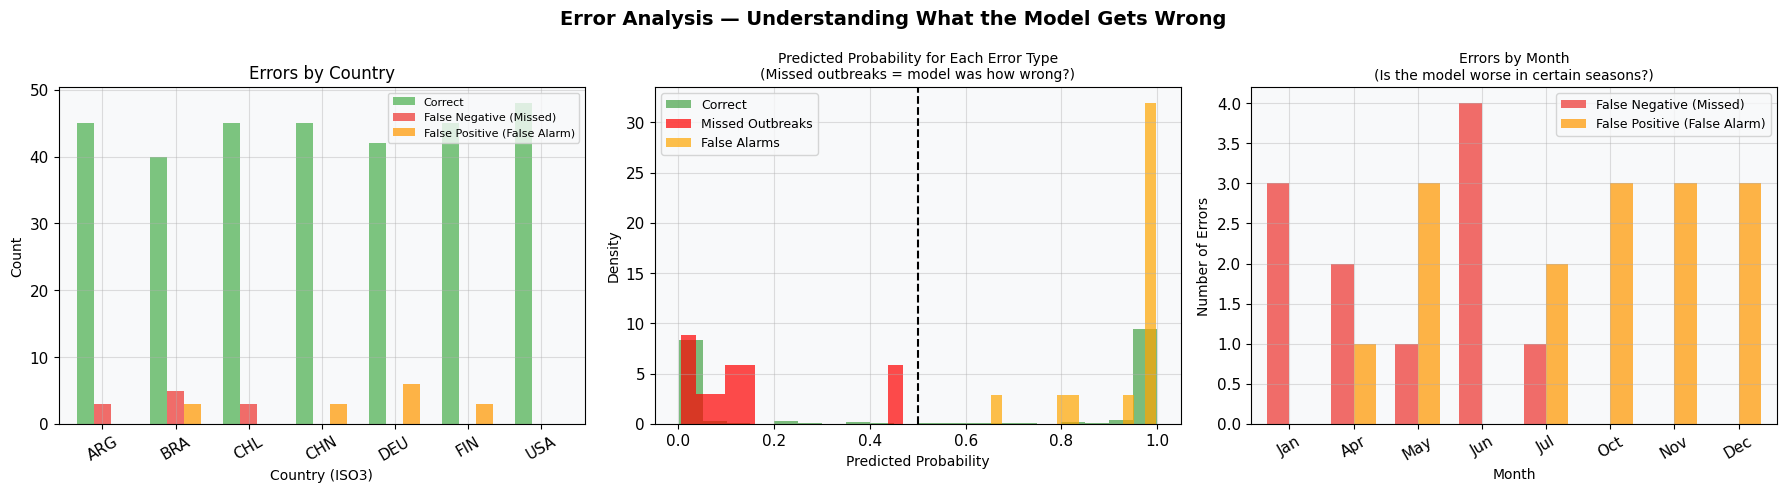


Error Type                      Count       %
────────────────────────────────────────────
Correct                           310  ( 92.3%)
False Positive (False Alarm)       15  (  4.5%)
False Negative (Missed)            11  (  3.3%)

Missed outbreaks had avg predicted prob: 0.149
(How far was the model from catching them?)


In [206]:
 
# ─────────────────────────────────────────────────────────────
# CELL 10: ERRORS ANALYSIS — What did the model get WRONG?
# ─────────────────────────────────────────────────────────────
test_eval = test_data.copy()
test_eval['predicted']    = model.predict(X_test)
test_eval['predicted_prob'] = model.predict_proba(X_test)[:, 1]
test_eval['correct']      = (test_eval['predicted'] == test_eval['target'])
test_eval['error_type']   = 'Correct'
test_eval.loc[(test_eval['target']==1) & (test_eval['predicted']==0), 'error_type'] = 'False Negative (Missed)'
test_eval.loc[(test_eval['target']==0) & (test_eval['predicted']==1), 'error_type'] = 'False Positive (False Alarm)'
 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Error Analysis — Understanding What the Model Gets Wrong',
             fontsize=14, fontweight='bold')
 
# Error breakdown by country
pivot = (test_eval.groupby(['iso3', 'error_type'])
         .size().unstack(fill_value=0))
pivot.plot(kind='bar', ax=axes[0],
           color=['#66BB6A', '#EF5350', '#FFA726'],
           alpha=0.85, width=0.7)
axes[0].set_title('Errors by Country', fontsize=12)
axes[0].set_xlabel('Country (ISO3)', fontsize=10)
axes[0].set_ylabel('Count', fontsize=10)
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(fontsize=8)
 
# Predicted probability distribution of errors
fn_probs = test_eval[test_eval['error_type'] == 'False Negative (Missed)']['predicted_prob']
fp_probs = test_eval[test_eval['error_type'] == 'False Positive (False Alarm)']['predicted_prob']
correct_probs = test_eval[test_eval['error_type'] == 'Correct']['predicted_prob']
 
axes[1].hist(correct_probs, bins=20, alpha=0.5, color='green',  label='Correct', density=True)
axes[1].hist(fn_probs,      bins=15, alpha=0.7, color='red',    label='Missed Outbreaks', density=True)
axes[1].hist(fp_probs,      bins=15, alpha=0.7, color='orange', label='False Alarms', density=True)
axes[1].axvline(x=0.5, color='black', linestyle='--', lw=1.5)
axes[1].set_title('Predicted Probability for Each Error Type\n(Missed outbreaks = model was how wrong?)', fontsize=10)
axes[1].set_xlabel('Predicted Probability', fontsize=10)
axes[1].set_ylabel('Density', fontsize=10)
axes[1].legend(fontsize=9)
 
# Errors by month (seasonal pattern?)
error_month = (test_eval[test_eval['error_type'] != 'Correct']
               .groupby(['month', 'error_type']).size().unstack(fill_value=0))
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
error_month.index = [month_names[i-1] for i in error_month.index]
error_month.plot(kind='bar', ax=axes[2],
                 color=['#EF5350', '#FFA726'], alpha=0.85, width=0.7)
axes[2].set_title('Errors by Month\n(Is the model worse in certain seasons?)', fontsize=10)
axes[2].set_xlabel('Month', fontsize=10)
axes[2].set_ylabel('Number of Errors', fontsize=10)
axes[2].tick_params(axis='x', rotation=30)
axes[2].legend(fontsize=9)
 
plt.tight_layout()
plt.savefig('error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
 
print(f"\n{'Error Type':<30} {'Count':>6} {'%':>7}")
print("─" * 44)
for etype, count in test_eval['error_type'].value_counts().items():
    print(f"{etype:<30} {count:>6}  ({count/len(test_eval)*100:>5.1f}%)")
 
if len(fn_probs) > 0:
    print(f"\nMissed outbreaks had avg predicted prob: {fn_probs.mean():.3f}")
    print(f"(How far was the model from catching them?)")

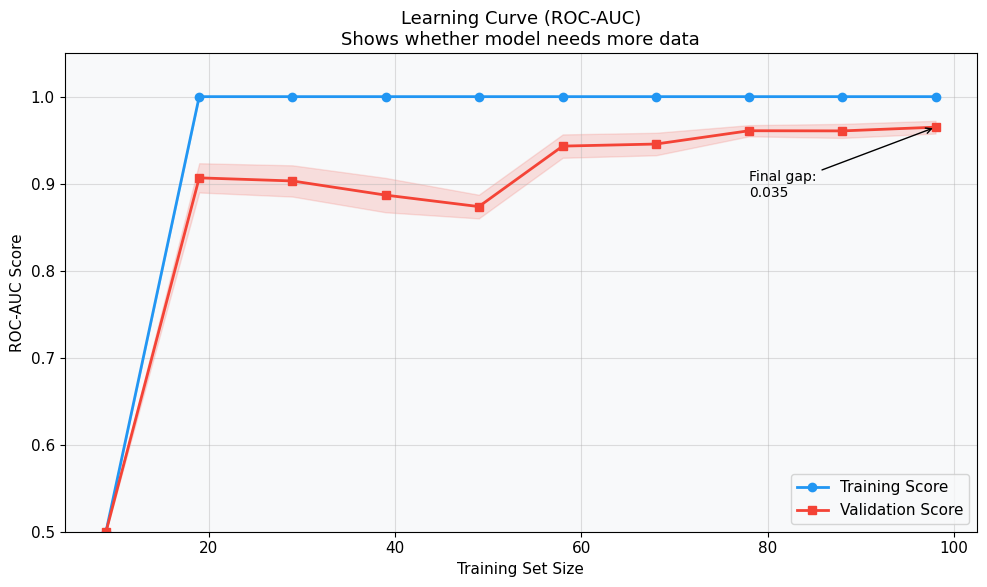


📊 Learning Curve Interpretation:
  Training AUC (final): 1.0000
  Validation AUC (final): 0.9649
  Gap: 0.0351
  ✅ Small gap + high score → good generalization!


In [207]:
 
# ─────────────────────────────────────────────────────────────
# CELL 11: LEARNING CURVE
# Does the model improve with more training data?
# ─────────────────────────────────────────────────────────────
from sklearn.model_selection import learning_curve
 
train_sizes, train_scores, val_scores = learning_curve(
    XGBClassifier(eval_metric='logloss', random_state=42, **best_params),
    X_train, y_train,
    cv=TimeSeriesSplit(n_splits=5),
    scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)
 
train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)
 
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(train_sizes, train_mean, 'o-', color='#2196F3', lw=2, label='Training Score')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#2196F3')
ax.plot(train_sizes, val_mean, 's-', color='#F44336', lw=2, label='Validation Score')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='#F44336')
 
ax.set_title('Learning Curve (ROC-AUC)\n'
             'Shows whether model needs more data',
             fontsize=13)
ax.set_xlabel('Training Set Size', fontsize=11)
ax.set_ylabel('ROC-AUC Score', fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim([0.5, 1.05])
 
gap = train_mean[-1] - val_mean[-1]
ax.annotate(f'Final gap:\n{gap:.3f}', xy=(train_sizes[-1], val_mean[-1]),
            xytext=(train_sizes[-3], val_mean[-1] - 0.08),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=10, color='black')
 
plt.tight_layout()
plt.savefig('learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()
 
print("\n📊 Learning Curve Interpretation:")
print(f"  Training AUC (final): {train_mean[-1]:.4f}")
print(f"  Validation AUC (final): {val_mean[-1]:.4f}")
print(f"  Gap: {gap:.4f}")
if gap > 0.1:
    print("  ⚠ Large gap → possible OVERFITTING")
elif val_mean[-1] < 0.75:
    print("  ⚠ Low validation score → possible UNDERFITTING")
else:
    print("  ✅ Small gap + high score → good generalization!")

In [208]:
# ─────────────────────────────────────────────────────────────
# CELL 12: FINAL SUMMARY TABLE
# ─────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("       COMPLETE MODEL EVALUATION SUMMARY")
print("="*60)
 
report = classification_report(y_test, y_pred, output_dict=True)
cm_final = confusion_matrix(y_test, y_pred)
tn_f, fp_f, fn_f, tp_f = cm_final.ravel()
 
summary = {
    "Accuracy":                f"{report['accuracy']:.4f}",
    "ROC-AUC":                 f"{roc_auc:.4f}",
    "Average Precision":       f"{ap_score:.4f}",
    "Precision (Outbreak)":    f"{report['1']['precision']:.4f}",
    "Recall (Outbreak)":       f"{report['1']['recall']:.4f}",
    "F1 Score (Outbreak)":     f"{report['1']['f1-score']:.4f}",
    "Precision (No Outbreak)": f"{report['0']['precision']:.4f}",
    "Recall (No Outbreak)":    f"{report['0']['recall']:.4f}",
    "F1 Score (No Outbreak)":  f"{report['0']['f1-score']:.4f}",
    "CV ROC-AUC (mean)":       f"{cv_scores_auc.mean():.4f} ± {cv_scores_auc.std():.4f}",
    "CV F1 (mean)":            f"{cv_scores_f1.mean():.4f} ± {cv_scores_f1.std():.4f}",
    "True Positives":          f"{tp_f}",
    "True Negatives":          f"{tn_f}",
    "False Positives":         f"{fp_f}  ← false alarms",
    "False Negatives":         f"{fn_f}  ← missed outbreaks ⚠",
    "Miss Rate":               f"{fn_f/(fn_f+tp_f)*100:.1f}%",
    "False Alarm Rate":        f"{fp_f/(fp_f+tn_f)*100:.1f}%",
}
 
for k, v in summary.items():
    print(f"  {k:<30} {v}")
 
print("="*60)
print("\nAll plots saved as PNG files.")


       COMPLETE MODEL EVALUATION SUMMARY
  Accuracy                       0.9226
  ROC-AUC                        0.9565
  Average Precision              0.9530
  Precision (Outbreak)           0.9167
  Recall (Outbreak)              0.9375
  F1 Score (Outbreak)            0.9270
  Precision (No Outbreak)        0.9295
  Recall (No Outbreak)           0.9062
  F1 Score (No Outbreak)         0.9177
  CV ROC-AUC (mean)              0.9855 ± 0.0116
  CV F1 (mean)                   0.9455 ± 0.0163
  True Positives                 165
  True Negatives                 145
  False Positives                15  ← false alarms
  False Negatives                11  ← missed outbreaks ⚠
  Miss Rate                      6.2%
  False Alarm Rate               9.4%

All plots saved as PNG files.


**Horizons**

In [209]:
horizons = [1, 2, 3, 6]
horizon_results = []

for h in horizons:
    monthly[f"future_cases_h{h}"] = monthly.groupby("iso3")["cases"].shift(-h)
    monthly[f"target_h{h}"] = (monthly[f"future_cases_h{h}"] >= THRESHOLD).astype(int)

    # SAFE: merge on actual keys (iso3, year, month), not index
    target_map = monthly[["iso3", "year", "month", f"target_h{h}"]]

    # drop the OLD target column first, so there's no duplicate "target" column
    data_h = data.drop(columns=["target"], errors="ignore").merge(
        target_map, on=["iso3", "year", "month"], how="left"
    )
    data_h = data_h.rename(columns={f"target_h{h}": "target"})

    data_h = data_h.sort_values(["year", "month"])
    train_h = data_h[data_h["year"] < 2022]
    test_h  = data_h[data_h["year"] >= 2022]

    X_tr = train_h[features].fillna(train_h[features].median())
    X_te = test_h[features].fillna(train_h[features].median())
    y_tr = train_h["target"]
    y_te = test_h["target"]

    clf = XGBClassifier(eval_metric="logloss", random_state=42, **grid_search.best_params_)
    clf.fit(X_tr, y_tr)

    preds = clf.predict(X_te)
    probs = clf.predict_proba(X_te)[:, 1]

    horizon_results.append({
        "Horizon (months)": h,
        "Accuracy": round(accuracy_score(y_te, preds) * 100, 4),
        "AUC": round(roc_auc_score(y_te, probs) * 100, 4),
        "F1": round(f1_score(y_te, preds) * 100, 4),
    })

horizon_df = pd.DataFrame(horizon_results)
print(horizon_df.to_string(index=False))

 Horizon (months)  Accuracy     AUC      F1
                1   92.2619 97.2171 92.8177
                2   92.2619 96.0147 92.8571
                3   92.2619 95.6499 92.6966
                6   86.0119 92.2594 86.3768


# THRESHOLD

In [210]:
from sklearn.metrics import confusion_matrix

thresholds = np.arange(0.05, 0.95, 0.05)
results = []

for t in thresholds:
    preds = (y_prob >= t).astype(int)
    tn_, fp_, fn_, tp_ = confusion_matrix(y_test, preds).ravel()
    results.append({
        'threshold': t,
        'precision': tp_ / (tp_ + fp_) if (tp_ + fp_) > 0 else 0,
        'recall':    tp_ / (tp_ + fn_) if (tp_ + fn_) > 0 else 0,
        'f1':        2*tp_ / (2*tp_ + fp_ + fn_) if (2*tp_ + fp_ + fn_) > 0 else 0,
        'accuracy':  (tp_ + tn_) / len(y_test),
        'fn_rate':   fn_ / (fn_ + tp_) if (fn_ + tp_) > 0 else 0,
        'fp_rate':   fp_ / (fp_ + tn_) if (fp_ + tn_) > 0 else 0
    })

df_thresh = pd.DataFrame(results)
df_thresh["threshold"] = df_thresh["threshold"].round(2)   # fix floating-point precision

threshold_table = df_thresh.copy()
threshold_table["threshold"] = threshold_table["threshold"].round(2)
for col in ["precision", "recall", "f1", "accuracy", "fn_rate", "fp_rate"]:
    threshold_table[col] = (threshold_table[col] * 100).round(2)

threshold_table = threshold_table.rename(columns={
    "threshold": "Threshold",
    "precision": "Precision (%)",
    "recall": "Recall (%)",
    "f1": "F1 (%)",
    "accuracy": "Accuracy (%)",
    "fn_rate": "Miss Rate / FN (%)",
    "fp_rate": "False Alarm / FP (%)"
})

print("=" * 90)
print("       FULL THRESHOLD SENSITIVITY ANALYSIS (0.05 → 0.90)")
print("=" * 90)
print(threshold_table.to_string(index=False))

best_f1_row      = df_thresh.loc[df_thresh["f1"].idxmax()]
default_row      = df_thresh[df_thresh["threshold"] == 0.50].iloc[0]
recommended_row  = df_thresh[df_thresh["threshold"] == 0.35].iloc[0]  # public-health pick

print("\n" + "=" * 90)
print("       WHY THIS THRESHOLD IS BEST — COMPARISON")
print("=" * 90)
print(f"Default (0.50):      F1={default_row.f1*100:.2f}%  Recall={default_row.recall*100:.2f}%  "
      f"Precision={default_row.precision*100:.2f}%  Miss Rate={default_row.fn_rate*100:.2f}%")
print(f"Best-F1 ({best_f1_row.threshold:.2f}):    F1={best_f1_row.f1*100:.2f}%  Recall={best_f1_row.recall*100:.2f}%  "
      f"Precision={best_f1_row.precision*100:.2f}%  Miss Rate={best_f1_row.fn_rate*100:.2f}%")
print(f"Recommended (0.35):  F1={recommended_row.f1*100:.2f}%  Recall={recommended_row.recall*100:.2f}%  "
      f"Precision={recommended_row.precision*100:.2f}%  Miss Rate={recommended_row.fn_rate*100:.2f}%")

threshold_table.to_csv("threshold_sensitivity_table.csv", index=False)

       FULL THRESHOLD SENSITIVITY ANALYSIS (0.05 → 0.90)
 Threshold  Precision (%)  Recall (%)  F1 (%)  Accuracy (%)  Miss Rate / FN (%)  False Alarm / FP (%)
      0.05          84.80       98.30   91.05         89.88                1.70                 19.38
      0.10          86.80       97.16   91.69         90.77                2.84                 16.25
      0.15          87.56       96.02   91.60         90.77                3.98                 15.00
      0.20          87.43       94.89   91.01         90.18                5.11                 15.00
      0.25          89.30       94.89   92.01         91.37                5.11                 12.50
      0.30          89.78       94.89   92.27         91.67                5.11                 11.88
      0.35          89.78       94.89   92.27         91.67                5.11                 11.88
      0.40          91.26       94.89   93.04         92.56                5.11                 10.00
      0.45          91.76

# ABLATION STUDY


In [211]:
# ============================================================
# ABLATION STUDY
# Measures how much each data source (Case Trends, Environmental,
# Clinical, Outbreak History) contributes to model performance.
#
# Full combinatorial design over the 4 sources:
#   1) All SINGLE sources           (4 combos  -> "choose 1")
#   2) All PAIRS of sources         (6 combos  -> "choose 2")
#   3) All TRIPLES of sources       (4 combos  -> "choose 3")
#   4) ALL 4 sources combined       (1 combo   -> full model)
#   => 15 configurations total, every source treated identically.
#
# No plots — results are reported as a table only.
# ============================================================

from itertools import combinations
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    precision_score, recall_score
)
from xgboost import XGBClassifier

# ------------------------------------------------------------
# Group the existing features by their data source
# (Case Trends = monthly_trends.csv | Environmental = environmental.csv
#  Clinical = clinical.csv | Outbreak History = outbreaks.csv)
# ------------------------------------------------------------
feature_groups = {
    "Monthly Trends": [   # from hantavirus_monthly_trends.csv
        "lag_1", "lag_2", "lag_3", "lag_6", "lag_12",
        "rolling_mean_3", "rolling_std_3", "rolling_max_6", "rolling_min_6",
        "sin_month", "cos_month", "regional_avg_cases"
    ],
    "Environmental": [   # from hantavirus_environmental.csv
        "avg_temp_c", "rainfall_mm", "humidity_pct", "ndvi",
        "rodent_abundance_index", "deforestation_km2",
        "temp_anomaly", "rainfall_anomaly", "latitude", "longitude"
    ],
    "Clinical": [   # from hantavirus_clinical.csv
        "icu_rate", "ventilator_rate", "avg_hospital_days",
        "pulmonary_edema_rate", "thrombocytopenia_rate"
    ],
    "Outbreak History": [   # from hantavirus_outbreaks.csv
        "historical_cases", "historical_deaths", "historical_cfr"
    ]
}

source_names = list(feature_groups.keys())

# ------------------------------------------------------------
# Build every combination: choose-1, choose-2, choose-3, choose-4
# ------------------------------------------------------------
ablation_configs = {}

for r in range(1, len(source_names) + 1):
    for combo in combinations(source_names, r):
        if r == len(source_names):
            continue
        else:
            label = " + ".join(combo)
        ablation_configs[label] = list(combo)

# ------------------------------------------------------------
# Train + evaluate each configuration
# ------------------------------------------------------------

# Use the same best hyperparameters found by GridSearchCV so the
# comparison across feature sets is fair
try:
    ablation_params = grid_search.best_params_
except NameError:
    ablation_params = dict(
        n_estimators=200, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8
    )

ablation_results = []

for config_name, group_names in ablation_configs.items():
    feat_subset = []
    for g in group_names:
        feat_subset.extend(feature_groups[g])

    # Fill missing values using ONLY the training split (no leakage)
    subset_median = train_data[feat_subset].median()
    X_tr = train_data[feat_subset].fillna(subset_median)
    X_te = test_data[feat_subset].fillna(subset_median)

    clf = XGBClassifier(eval_metric="logloss", random_state=42, **ablation_params)
    clf.fit(X_tr, y_train)

    preds = clf.predict(X_te)
    probs = clf.predict_proba(X_te)[:, 1]

    ablation_results.append({
        "N_Sources":   len(group_names),
        "Features":    config_name,
        "N_Features":  len(feat_subset),
        "Accuracy":    round(accuracy_score(y_test, preds) * 100, 1),
        "AUC":         round(roc_auc_score(y_test, probs) * 100, 1),
        "F1":          round(f1_score(y_test, preds) * 100, 1),
        "Precision":   round(precision_score(y_test, preds) * 100, 1),
        "Recall":      round(recall_score(y_test, preds) * 100, 1),
    })

ablation_df = pd.DataFrame(ablation_results)

# Sort by number of sources used (1 -> 2 -> 3 -> 4), so it reads
# exactly as: all singles, then all pairs, then all triples, then all 4
ablation_df = ablation_df.sort_values(
    ["N_Sources", "Features"]
).reset_index(drop=True)

print("\n" + "=" * 90)
print("       ABLATION STUDY — ALL FEATURE SOURCE COMBINATIONS")
print("       (1 source -> 2 sources -> 3 sources -> all 4 sources)")
print("=" * 90)
print(ablation_df.drop(columns="N_Sources").to_string(index=False))

ablation_df.to_csv("ablation_study_results.csv", index=False)

ablation_df



       ABLATION STUDY — ALL FEATURE SOURCE COMBINATIONS
       (1 source -> 2 sources -> 3 sources -> all 4 sources)
                                         Features  N_Features  Accuracy  AUC   F1  Precision  Recall
                                         Clinical           5      86.9 91.9 88.0       84.4    92.0
                                    Environmental          10      65.2 73.0 74.5       60.4    97.2
                                   Monthly Trends          12      90.2 94.9 90.7       89.9    91.5
                                 Outbreak History           3      52.4 49.0 68.8       52.4   100.0
                      Clinical + Outbreak History           8      86.9 91.9 88.0       84.4    92.0
                         Environmental + Clinical          15      88.1 92.8 89.0       86.2    92.0
                 Environmental + Outbreak History          13      65.2 72.7 74.5       60.4    97.2
                        Monthly Trends + Clinical          17      92.3 95

,N_Sources,Features,N_Features,Accuracy,AUC,F1,Precision,Recall
0,1,Clinical,5,86.9,91.9,88.0,84.4,92.0
1,1,Environmental,10,65.2,73.0,74.5,60.4,97.2
2,1,Monthly Trends,12,90.2,94.9,90.7,89.9,91.5
3,1,Outbreak History,3,52.4,49.0,68.8,52.4,100.0
4,2,Clinical + Outbreak History,8,86.9,91.9,88.0,84.4,92.0
5,2,Environmental + Clinical,15,88.1,92.8,89.0,86.2,92.0
6,2,Environmental + Outbreak History,13,65.2,72.7,74.5,60.4,97.2
7,2,Monthly Trends + Clinical,17,92.3,95.4,92.7,91.7,93.8
8,2,Monthly Trends + Environmental,22,92.0,95.2,92.4,91.6,93.2
9,2,Monthly Trends + Outbreak History,15,90.2,94.9,90.7,89.9,91.5


# Save Model + All Records (.pkl)


In [212]:
# ============================================================
# SAVE BEST MODEL + LABEL ENCODER + IMPUTATION VALUES
# + FULL TRAIN/TEST SPLIT RECORDS  ->  ALL AS .pkl
# ============================================================
import joblib
import os

SAVE_DIR = "/kaggle/working"
os.makedirs(SAVE_DIR, exist_ok=True)

# ------------------------------------------------------------
# 1) Best trained model (XGBoost, from GridSearchCV)
# ------------------------------------------------------------
joblib.dump(model, os.path.join(SAVE_DIR, "best_model.pkl"))

# ------------------------------------------------------------
# 2) Label encoder used for iso3 -> iso3_encoded
# ------------------------------------------------------------
joblib.dump(le, os.path.join(SAVE_DIR, "label_encoder.pkl"))

# ------------------------------------------------------------
# 3) Median values used to fill missing data (fit on TRAIN only,
#    same values must be reused at inference time on new data)
# ------------------------------------------------------------
joblib.dump(train_median, os.path.join(SAVE_DIR, "train_median_imputer.pkl"))

# ------------------------------------------------------------
# 4) Feature list + best hyperparameters (needed to rebuild /
#    reuse the model correctly later)
# ------------------------------------------------------------
joblib.dump(features, os.path.join(SAVE_DIR, "feature_list.pkl"))
joblib.dump(grid_search.best_params_, os.path.join(SAVE_DIR, "best_params.pkl"))

# ------------------------------------------------------------
# 5) Train / Test split records (features + targets), and the
#    full row-level train_data / test_data (with all original
#    columns: iso3, year, month, target, predictions, etc.)
# ------------------------------------------------------------
joblib.dump(X_train, os.path.join(SAVE_DIR, "X_train.pkl"))
joblib.dump(X_test,  os.path.join(SAVE_DIR, "X_test.pkl"))
joblib.dump(y_train, os.path.join(SAVE_DIR, "y_train.pkl"))
joblib.dump(y_test,  os.path.join(SAVE_DIR, "y_test.pkl"))

joblib.dump(train_data, os.path.join(SAVE_DIR, "train_data_full.pkl"))
joblib.dump(test_data,  os.path.join(SAVE_DIR, "test_data_full.pkl"))

# Full merged dataset before the temporal split (all engineered features)
joblib.dump(data, os.path.join(SAVE_DIR, "data_full.pkl"))

print("Saved to", SAVE_DIR, ":")
for f in sorted(os.listdir(SAVE_DIR)):
    if f.endswith(".pkl"):
        print(" -", f)

print("\nGo to the Kaggle notebook's right-side panel -> 'Output' tab "
      "(after committing / running all cells) to download these .pkl files.")


Saved to /kaggle/working :
 - X_test.pkl
 - X_train.pkl
 - best_model.pkl
 - best_params.pkl
 - data_full.pkl
 - feature_list.pkl
 - label_encoder.pkl
 - test_data_full.pkl
 - train_data_full.pkl
 - train_median_imputer.pkl
 - y_test.pkl
 - y_train.pkl

Go to the Kaggle notebook's right-side panel -> 'Output' tab (after committing / running all cells) to download these .pkl files.
